# 04 Evaluation

Evaluate the trained EfficientNet-B0 image model on the test split.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

DATA_ROOT = Path("../../data/splits/images")
MODEL_PATH = Path("../../models/image/best_model.pth")
SPLITS = ["train", "val", "test"]
CLASSES = ["real", "fake"]
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
BATCH_SIZE = 32
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Model path exists: {MODEL_PATH.exists()} | {MODEL_PATH}")

Using device: cuda
Model path exists: True | ..\models\image\best_model.pth


In [2]:
def collect_image_paths(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for class_name in CLASSES:
            class_dir = data_root / split / class_name
            print(f"Scanning {class_dir} | exists={class_dir.exists()}")
            if not class_dir.exists():
                continue
            for path in sorted(class_dir.iterdir()):
                if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                    rows.append({"path": str(path), "split": split, "label": class_name, "label_id": 1 if class_name == "fake" else 0})
    return pd.DataFrame(rows)


df = collect_image_paths(DATA_ROOT)
print(f"Loaded records: {len(df)}")
display(df.head())
display(df.groupby(["split", "label"]).size().unstack(fill_value=0))

Scanning ..\data\splits\images\train\real | exists=True
Scanning ..\data\splits\images\train\fake | exists=True
Scanning ..\data\splits\images\val\real | exists=True
Scanning ..\data\splits\images\val\fake | exists=True
Scanning ..\data\splits\images\test\real | exists=True
Scanning ..\data\splits\images\test\fake | exists=True
Loaded records: 57098


,path,split,label,label_id
0,..\data\splits\images\train\real\real_100.jpg,train,real,0
1,..\data\splits\images\train\real\real_10001.jpg,train,real,0
2,..\data\splits\images\train\real\real_10002.jpg,train,real,0
3,..\data\splits\images\train\real\real_10006.jpg,train,real,0
4,..\data\splits\images\train\real\real_10013.jpg,train,real,0


label,fake,real
split,,
test,1647,1623
train,21000,21000
val,5892,5936


In [3]:
eval_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class DeepfakeImageDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        print(f"Dataset initialized with {len(self.dataframe)} images")

    def __len__(self):
        return len(self.dataframe)

    def _load_image(self, path: str):
        try:
            with Image.open(path) as image:
                return image.convert("RGB")
        except (OSError, UnidentifiedImageError) as error:
            print(f"Warning: corrupted image replaced with blank tensor: {path} | {error}")
            return Image.new("RGB", (224, 224), color=(0, 0, 0))

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = self._load_image(row["path"])
        label = torch.tensor(row["label_id"], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

In [4]:
test_dataset = DeepfakeImageDataset(df[df["split"] == "test"], transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Test size: {len(test_dataset)} | Test batches: {len(test_loader)}")
images, labels = next(iter(test_loader))
print(f"Debug test batch images: {images.shape}")
print(f"Debug test batch labels: {labels.shape}")
print(f"Debug test labels: {labels[:10].tolist()}")

Dataset initialized with 3270 images
Test size: 3270 | Test batches: 103
Debug test batch images: torch.Size([32, 3, 224, 224])
Debug test batch labels: torch.Size([32])
Debug test labels: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [5]:
def build_model() -> nn.Module:
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 1)
    return model


model = build_model().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Loaded trained image model")
print(model.classifier)

Loaded trained image model
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1, bias=True)
)


C:\Users\Asus\AppData\Local\Temp\ipykernel_18780\2494966039.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=dev

In [6]:
def predict(model, loader):
    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            probabilities = torch.sigmoid(logits).view(-1).cpu()
            predictions = (probabilities >= 0.5).long()

            if batch_idx == 0:
                print(f"Evaluation logits: {logits[:5].detach().cpu().view(-1).tolist()}")
                print(f"Evaluation probabilities: {probabilities[:5].tolist()}")
                print(f"Evaluation predictions: {predictions[:5].tolist()}")

            all_labels.extend(labels.long().tolist())
            all_predictions.extend(predictions.tolist())
            all_probabilities.extend(probabilities.tolist())

    return all_labels, all_predictions, all_probabilities


y_true, y_pred, y_prob = predict(model, test_loader)
print(f"Predictions generated: {len(y_pred)}")

Evaluation logits: [-0.31661856174468994, 0.5382258892059326, -18.839397430419922, -16.97504425048828, -12.874994277954102]
Evaluation probabilities: [0.4215000569820404, 0.6313996911048889, 6.578905864529361e-09, 4.244552798127188e-08, 2.5612969238864025e-06]
Evaluation predictions: [0, 1, 0, 0, 0]
Predictions generated: 3270


In [7]:
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
}

for name, value in metrics.items():
    print(f"{name}: {value:.4f}")

metrics

accuracy: 0.8657
precision: 0.8075
recall: 0.9630
f1: 0.8784


{'accuracy': 0.8657492354740061,
 'precision': 0.8075356415478615,
 'recall': 0.9629629629629629,
 'f1': 0.8784270285239546}

Confusion matrix:
[[1245  378]
 [  61 1586]]


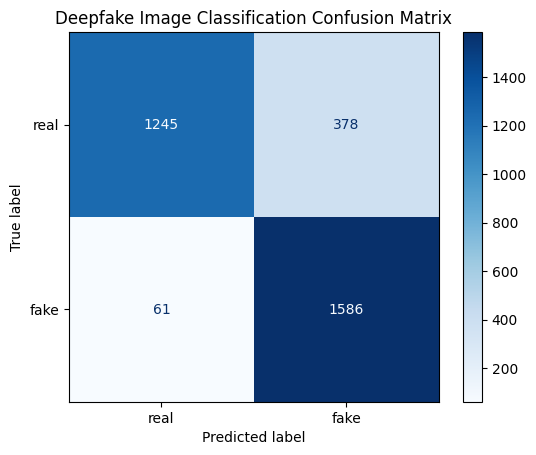

In [8]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("Confusion matrix:")
print(cm)

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["real", "fake"])
display.plot(cmap="Blues", values_format="d")
plt.title("Deepfake Image Classification Confusion Matrix")
plt.show()